# 가설 2 (H2) 분석 — 유가 → 시차를 둔 물가 전이

## 분석 개요
- **가설**: 유가 상승이 일정 시차를 두고 국내 CPI에 전이된다.
- **기간**: 2026년 1월 ~ 4월 (CPI 4개월 / 유가는 2026-01-02 ~ 2026-05-20 일별)
- **사건**: 2026-02-28 이란 전쟁 발생
- **데이터 출처**: 국내 유가(오피넷 휘발유가), 국제 유가(WTI), CPI(통계청)

## 분석 절차
1. SQLite DB 구축 → SQL로 월별 집계 (oil_sql 방식)
2. 일별 유가 + 월별 CPI 시계열 시각화 (이중축)
3. 월별 변동률(전월비) 비교
4. 전쟁 시점 기준 t-1 / t0 / t+1 / t+2 이벤트 스터디
5. 부문별 CPI 분해 분석

## 한계 명시
- 유가는 일별, CPI는 월별 → 주기 불일치 (유가를 월평균 집계로 해결)
- 부문별 CPI는 전년동월비만 있어 전월비 계산 불가 → 수준 비교로 대체
- N=4로 통계적 추론 불가 → 정성적 사례연구 수준

## 폰트설정

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform, os

system_os = platform.system()
if system_os == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_os == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:  # Linux / Colab
    import matplotlib.font_manager as fm
    font_url = 'https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf'
    font_path = './NanumGothic.ttf'
    if not os.path.exists(font_path):
        import urllib.request
        urllib.request.urlretrieve(font_url, font_path)
    fm.fontManager.addfont(font_path)
    prop = fm.FontProperties(fname=font_path)
    plt.rc('font', family=prop.get_name())

plt.rcParams['axes.unicode_minus'] = False

환경 설정 완료


## 1. 데이터 로드

### 1-1. SQLite DB 구축 및 유가 데이터 로드 (oil_sql 방식)
- `oil_sql.ipynb`과 동일하게 SQLite 인메모리 DB에 일별 데이터 삽입
- SQL 쿼리로 **월별 집계** 및 전쟁 전후 구간 필터링
- 국내 유가: 오피넷 휘발유 소비자가격 (원/L), 국제 유가: WTI (달러/배럴 → 원/배럴 환산값)
- 데이터 범위: 2026-01-02 ~ **2026-05-20** (5월 20일까지만 사용)

In [ ]:
import sqlite3
import pandas as pd

# SQLite 인메모리 DB 생성
conn   = sqlite3.connect(":memory:")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE oil_prices (
    date     TEXT,
    dubai    REAL,
    brent    REAL,
    wti      REAL,
    gasoline REAL
)
""")

# 일별 유가 원데이터 삽입 (2026-01-02 ~ 2026-05-20)
all_data = [
    ('2026-01-02',  544.41,  548.29,  517.33, 1727.62),
    ('2026-01-05',  528.46,  560.20,  529.00, 1726.61),
    ('2026-01-06',  540.64,  552.38,  519.89, 1725.26),
    ('2026-01-07',  530.05,  545.23,  509.13, 1724.70),
    ('2026-01-08',  531.37,  564.71,  526.17, 1723.51),
    ('2026-01-09',  554.47,  577.44,  538.97, 1721.21),
    ('2026-01-12',  562.19,  584.81,  544.79, 1718.51),
    ('2026-01-13',  568.66,  602.91,  563.13, 1715.74),
    ('2026-01-14',  578.24,  616.22,  574.54, 1713.11),
    ('2026-01-15',  581.20,  592.54,  550.07, 1710.98),
    ('2026-01-16',  576.01,  592.83,  549.48, 1710.16),
    ('2026-01-19',  574.25,  592.61,    None, 1708.30),
    ('2026-01-20',  573.00,  601.73,  559.28, 1705.99),
    ('2026-01-21',  579.06,  606.09,  563.17, 1704.20),
    ('2026-01-22',  585.65,  593.44,  549.90, 1702.63),
    ('2026-01-23',  575.31,  608.47,  564.05, 1701.14),
    ('2026-01-26',  586.38,  605.30,  559.53, 1699.39),
    ('2026-01-27',  570.73,  613.20,  566.19, 1698.66),
    ('2026-01-28',  589.14,  623.32,  576.02, 1697.69),
    ('2026-01-29',  596.11,  635.38,  587.85, 1696.20),
    ('2026-01-30',  597.51,  634.49,  585.30, 1694.81),
    ('2026-02-02',  587.20,  599.13,  561.54, 1693.81),
    ('2026-02-03',  596.72,  617.16,  579.40, 1692.91),
    ('2026-02-04',  608.82,  633.06,  593.69, 1692.03),
    ('2026-02-05',  615.40,  616.59,  577.70, 1691.81),
    ('2026-02-06',  623.73,  626.67,  585.23, 1691.46),
    ('2026-02-09',  617.86,  638.48,  595.20, 1690.64),
    ('2026-02-10',  626.21,  633.67,  589.09, 1689.83),
    ('2026-02-11',  628.89,  636.31,  592.58, 1689.26),
    ('2026-02-12',  628.29,  617.67,  574.86, 1688.93),
    ('2026-02-13',  607.19,  615.09,  570.97, 1688.60),
    ('2026-02-16',  608.83,  623.26,    None, 1688.43),
    ('2026-02-17',    None,  612.09,  565.88, 1688.53),
    ('2026-02-18',    None,  638.70,  591.85, 1688.07),
    ('2026-02-19',  636.66,  650.45,  602.98, 1687.54),
    ('2026-02-20',  645.21,  654.79,  605.79, 1687.15),
    ('2026-02-23',  638.22,  651.43,  604.23, 1686.86),
    ('2026-02-24',  639.16,  641.89,  595.27, 1686.30),
    ('2026-02-25',  637.39,  644.30,  594.92, 1686.05),
    ('2026-02-26',  636.74,  638.72,  588.71, 1686.21),
    ('2026-02-27',  638.31,  649.42,  600.50, 1686.05),
    ('2026-03-02',  723.88,  696.55,  638.22, 1686.24),
    ('2026-03-03',  743.41,  734.92,  673.17, 1686.62),
    ('2026-03-04',  795.33,  749.82,  687.73, 1687.33),
    ('2026-03-05',  882.99,  794.44,  753.51, 1687.62),
    ('2026-03-06',  924.90,  853.70,  837.22, 1687.97),
    ('2026-03-09', 1159.31,  917.80,  878.94, 1688.27),
    ('2026-03-10', 1081.90,  824.57,  783.72, 1688.43),
    ('2026-03-11', 1107.49,  852.08,  808.26, 1688.35),
    ('2026-03-12', 1240.40,  927.16,  883.51, 1688.27),
    ('2026-03-13', 1354.38,  960.01,  918.77, 1688.99),
    ('2026-03-16', 1435.68,  938.85,  875.98, 1689.69),
    ('2026-03-17', 1483.54,  973.15,  905.31, 1690.12),
    ('2026-03-18', 1459.38, 1007.44,  903.68, 1690.94),
    ('2026-03-19', 1559.05, 1015.53,  898.60, 1691.40),
    ('2026-03-20', 1498.43, 1058.29,  927.45, 1691.74),
    ('2026-03-23', 1596.13,  939.71,  828.67, 1692.08),
    ('2026-03-24', 1491.04,  992.16,  876.89, 1692.58),
    ('2026-03-25', 1343.42,  963.34,  851.19, 1692.89),
    ('2026-03-26', 1063.39, 1016.07,  888.79, 1695.89),
    ('2026-03-27', 1157.14, 1066.47,  943.98, 1702.07),
    ('2026-03-30', 1188.48, 1069.81,  975.90, 1723.04),
    ('2026-03-31', 1152.77, 1126.59,  965.05, 1777.48),
    ('2026-04-01', 1048.35,  973.84,  963.83, 1834.28),
    ('2026-04-02', 1086.86, 1034.03, 1057.84, 1871.82),
    ('2026-04-06', 1139.82, 1040.91, 1065.95, 1889.40),
    ('2026-04-07', 1155.25, 1035.90, 1070.78, 1895.32),
    ('2026-04-08',  959.14,  898.01,  894.78, 1902.67),
    ('2026-04-09',  947.02,  890.57,  908.68, 1906.95),
    ('2026-04-10',  939.70,  886.88,  899.64, 1904.28),
    ('2026-04-13',  991.28,  924.82,  922.22, 1898.78),
    ('2026-04-14',  966.87,  888.25,  855.36, 1864.07),
    ('2026-04-15',  941.94,  884.55,  850.63, 1845.31),
    ('2026-04-16',  943.24,  920.91,  877.37, 1840.09),
    ('2026-04-17',  946.63,  837.15,  776.66, 1832.70),
    ('2026-04-20',  916.94,  888.83,  834.18, 1827.50),
    ('2026-04-21',  874.96,  914.03,  855.09, 1824.35),
    ('2026-04-22',  928.82,  942.79,  859.99, 1822.05),
    ('2026-04-23',  974.10,  976.52,  890.83, 1820.38),
    ('2026-04-24',  998.34,  980.92,  879.13, 1819.83),
    ('2026-04-27',  971.91, 1009.49,  898.87, 1819.66),
    ('2026-04-28',  993.28, 1030.90,  925.92, 1819.26),
    ('2026-04-29',  986.83, 1093.78,  990.45, 1818.92),
    ('2026-04-30', 1041.73, 1058.53,  975.53, 1818.94),
    ('2026-05-01',    None, 1004.31,  946.47, 1819.35),
    ('2026-05-04',  960.45, 1068.79,  993.88, 1838.79),
    ('2026-05-05',  995.56, 1026.10,  955.13, 1855.86),
    ('2026-05-06',  959.06,  936.68,  879.42, 1864.76),
    ('2026-05-07',  894.23,  916.86,  868.76, 1881.09),
    ('2026-05-08',  888.72,  924.31,  870.75, 1894.96),
    ('2026-05-11',  932.34,  960.92,  904.30, 1909.78),
    ('2026-05-12',  971.90,  998.49,  946.70, 1921.28),
    ('2026-05-13',  979.36,  986.17,  943.13, 1931.84),
    ('2026-05-14',  992.13,  994.20,  951.41, 1942.44),
    ('2026-05-15', 1006.83, 1025.22,  989.19, 1948.40),
    ('2026-05-18', 1017.79, 1057.51, 1025.06, 1958.37),
    ('2026-05-19', 1009.93, 1052.29, 1019.10, 1968.38),
    ('2026-05-20', 1008.30,  993.36,  929.42, 1977.77),
]

cursor.executemany("""
INSERT INTO oil_prices (date, dubai, brent, wti, gasoline)
VALUES (?, ?, ?, ?, ?)
""", all_data)
conn.commit()

# SQL: 일별 데이터 전체 조회 (시각화용)
sql_daily = """
SELECT date, gasoline AS 국내유가, wti AS WTI
FROM oil_prices
WHERE date <= '2026-05-20'
ORDER BY date
"""
oil_df = pd.read_sql_query(sql_daily, conn)
oil_df['date'] = pd.to_datetime(oil_df['date'])

# 전쟁 기준일
WAR_DATE = pd.to_datetime('2026-02-28')

print(f"일별 데이터: {len(oil_df)}개 행 ({oil_df['date'].min().date()} ~ {oil_df['date'].max().date()})")
print(f"월별 분포: {oil_df.groupby(oil_df['date'].dt.month).size().to_dict()}")
oil_df.head()

일별 데이터: 98개 행 (2026-01-02 ~ 2026-05-20)
월별 분포: {1: 21, 2: 20, 3: 22, 4: 21, 5: 14}


,date,국내유가,WTI
0,2026-01-02,1727.62,517.33
1,2026-01-05,1726.61,529.00
2,2026-01-06,1725.26,519.89
3,2026-01-07,1724.70,509.13
4,2026-01-08,1723.51,526.17


### 1-2. 소비자물가지수

In [ ]:
cpi_df = pd.DataFrame({
    'month': pd.to_datetime(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01']),
    'CPI_지수': [118.03, 118.40, 118.80, 119.37],
    'CPI_전월비': [0.4, 0.3, 0.3, 0.5],
    # 부문별 전년동월비
    '총지수_전년동월비': [2.0, 2.0, 2.2, 2.6],
    '식료품에너지제외_전년동월비': [2.3, 2.3, 2.2, 2.2],
    '농산물석유류제외_전년동월비': [2.4, 2.5, 2.3, 2.2],
    '생활물가지수_전년동월비': [2.5, 2.3, 2.3, 2.9],
    '신선식품지수_전년동월비': [-0.2, -2.7, -6.6, -6.1],
})
cpi_df

,month,CPI_지수,CPI_전월비,총지수_전년동월비,식료품에너지제외_전년동월비,농산물석유류제외_전년동월비,생활물가지수_전년동월비,신선식품지수_전년동월비
0,2026-01-01,118.03,0.4,2.0,2.3,2.4,2.5,-0.2
1,2026-02-01,118.40,0.3,2.0,2.3,2.5,2.3,-2.7
2,2026-03-01,118.80,0.3,2.2,2.2,2.3,2.3,-6.6
3,2026-04-01,119.37,0.5,2.6,2.2,2.2,2.9,-6.1


## 2. 전처리 — SQL로 유가 월별 집계 + 전월비 계산

SQL `GROUP BY strftime('%Y-%m', date)`로 월평균 집계 후 pandas에서 전월비 계산

In [ ]:
# ── SQL: 월별 평균 집계 ──────────────────────────────────────────────────
sql_monthly = """
SELECT
    strftime('%Y-%m', date)  AS month,
    AVG(gasoline)            AS 유가_월평균,
    AVG(wti)                 AS WTI_월평균,
    COUNT(*)                 AS 관측일수
FROM oil_prices
WHERE date <= '2026-05-20'
GROUP BY strftime('%Y-%m', date)
ORDER BY month
"""

oil_monthly = pd.read_sql_query(sql_monthly, conn)
oil_monthly['month'] = pd.to_datetime(oil_monthly['month'] + '-01')

# ── 전월비 변동률 계산 (pandas) ──────────────────────────────────────────
oil_monthly['유가_전월비'] = oil_monthly['유가_월평균'].pct_change() * 100
oil_monthly['WTI_전월비']  = oil_monthly['WTI_월평균'].pct_change() * 100

# ── CPI와 병합 ────────────────────────────────────────────────────────────
merged = pd.merge(cpi_df, oil_monthly, on='month', how='outer').sort_values('month').reset_index(drop=True)

num_cols = merged.select_dtypes(include='number').columns
merged[num_cols] = merged[num_cols].round(2)

print("=== SQL 월별 집계 결과 ===")
print(oil_monthly.to_string(index=False))
print()
print("=== CPI + 유가 병합 결과 ===")
merged

=== SQL 월별 집계 결과 ===
     month      유가_월평균    WTI_월평균  관측일수    유가_전월비   WTI_전월비
2026-01-01 1710.781905 551.689500    21       NaN       NaN
2026-02-01 1689.023500 587.915263    20 -1.271840  6.566332
2026-03-01 1695.818636 850.206364    22  0.402312 44.613759
2026-04-01 1851.264762 916.844286    21  9.166436  7.837853
2026-05-01 1908.076429 944.480000    14  3.068803  3.014221

=== CPI + 유가 병합 결과 ===


,month,CPI_지수,CPI_전월비,총지수_전년동월비,식료품에너지제외_전년동월비,농산물석유류제외_전년동월비,생활물가지수_전년동월비,신선식품지수_전년동월비,유가_월평균,WTI_월평균,관측일수,유가_전월비,WTI_전월비
0,2026-01-01,118.03,0.4,2.0,2.3,2.4,2.5,-0.2,1710.78,551.69,21,NaN,NaN
1,2026-02-01,118.40,0.3,2.0,2.3,2.5,2.3,-2.7,1689.02,587.92,20,-1.27,6.57
2,2026-03-01,118.80,0.3,2.2,2.2,2.3,2.3,-6.6,1695.82,850.21,22,0.40,44.61
3,2026-04-01,119.37,0.5,2.6,2.2,2.2,2.9,-6.1,1851.26,916.84,21,9.17,7.84
4,2026-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1908.08,944.48,14,3.07,3.01


## 3. 시각화 1 — 일별 유가 vs 월별 CPI 이중축 시계열
두 시계열의 변곡점이 시각적으로 어느 시점에 발생하는지 비교

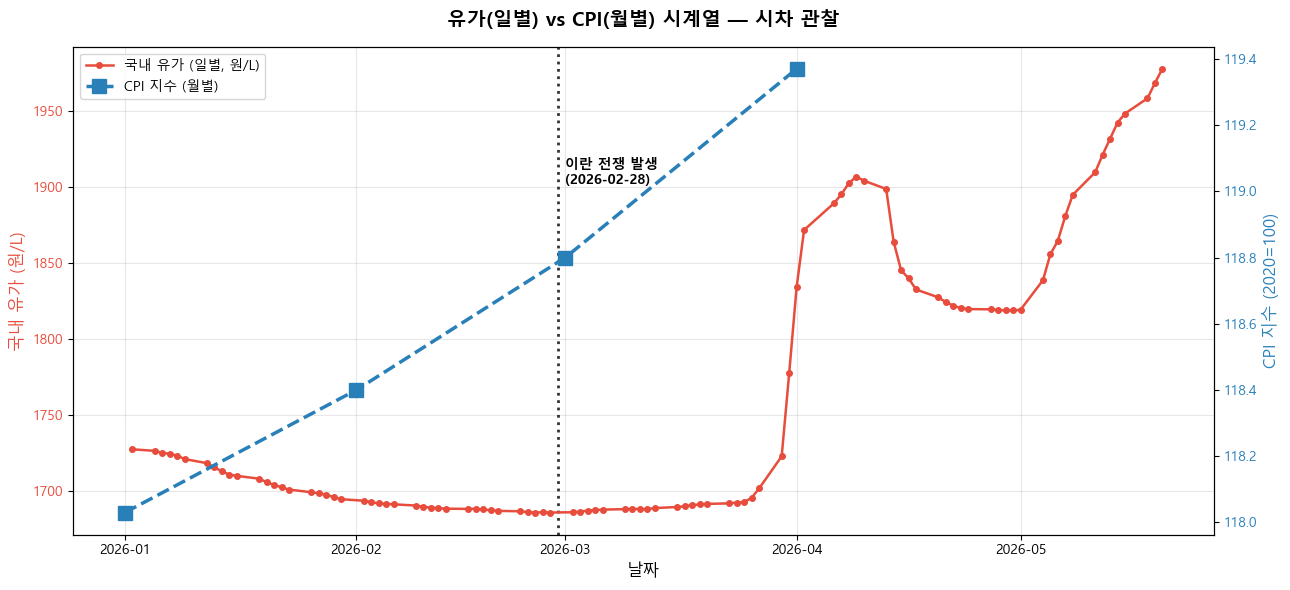

In [ ]:
fig, ax1 = plt.subplots(figsize=(13, 6))

# ── 좌축: 일별 국내유가 ─────────────────────────────────────────────────
color1 = '#e74c3c'
ax1.plot(oil_df['date'], oil_df['국내유가'], color=color1, marker='o', markersize=4,
         linewidth=1.8, label='국내 유가 (일별, 원/L)', zorder=3)
ax1.set_xlabel('날짜', fontsize=12)
ax1.set_ylabel('국내 유가 (원/L)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# ── 우축: 월별 CPI 지수 ──────────────────────────────────────────────────
ax2 = ax1.twinx()
color2 = '#2980b9'
ax2.plot(cpi_df['month'], cpi_df['CPI_지수'], color=color2, marker='s', markersize=10,
         linewidth=2.5, label='CPI 지수 (월별)', linestyle='--', zorder=3)
ax2.set_ylabel('CPI 지수 (2020=100)', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

# ── 전쟁 시점 표시 ──────────────────────────────────────────────────────
ax1.axvline(WAR_DATE, color='black', linestyle=':', linewidth=2, alpha=0.8, zorder=2)
ax1.text(WAR_DATE + pd.Timedelta(days=1),
         oil_df['국내유가'].max() * 0.97,
         '이란 전쟁 발생\n(2026-02-28)',
         fontsize=10, verticalalignment='top', color='black', fontweight='bold')

# ── 범례 통합 ────────────────────────────────────────────────────────────
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('유가(일별) vs CPI(월별) 시계열 — 시차 관찰', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

## 4. 시각화 2 — 월별 변동률 비교
유가 월평균 전월비 vs CPI 전월비.

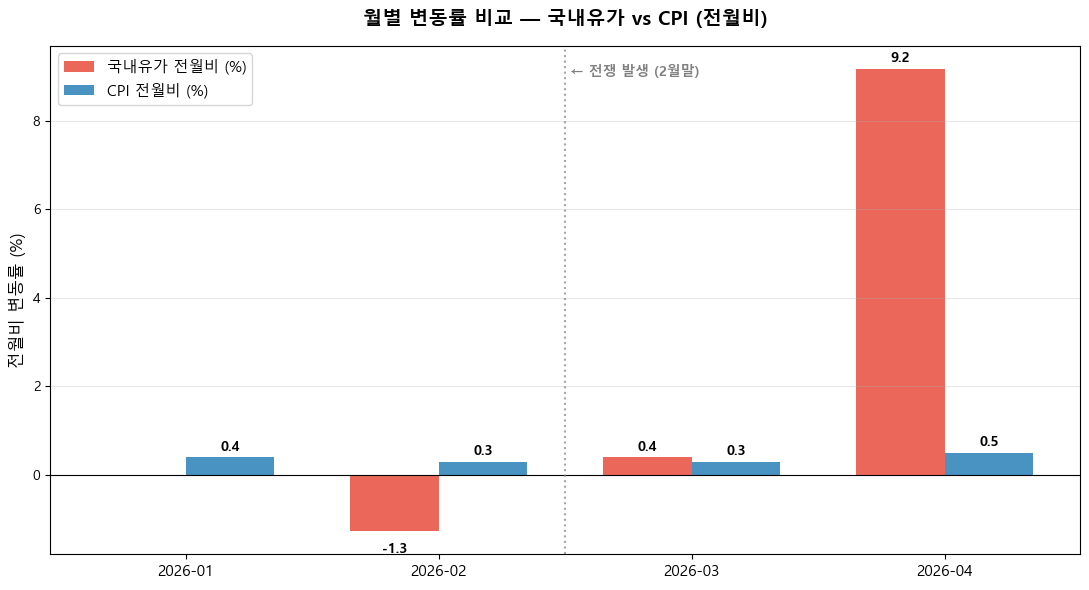

In [ ]:
# CPI가 있는 월(1~4월)만 표시
plot_df = merged[merged['CPI_지수'].notna()].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6))
x     = np.arange(len(plot_df))
width = 0.35

oil_chg = plot_df['유가_전월비'].tolist()
cpi_chg = plot_df['CPI_전월비'].tolist()

bars1 = ax.bar(x - width/2, [v if pd.notna(v) else 0 for v in oil_chg],
               width, label='국내유가 전월비 (%)', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + width/2, [v if pd.notna(v) else 0 for v in cpi_chg],
               width, label='CPI 전월비 (%)',    color='#2980b9', alpha=0.85)

for bars, vals in [(bars1, oil_chg), (bars2, cpi_chg)]:
    for bar, v in zip(bars, vals):
        if pd.notna(v):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.15 if v >= 0 else bar.get_height() - 0.5,
                    f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([m.strftime('%Y-%m') for m in plot_df['month']], fontsize=11)
ax.set_ylabel('전월비 변동률 (%)', fontsize=12)
ax.set_title('월별 변동률 비교 — 국내유가 vs CPI (전월비)', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(0, color='black', linewidth=0.8)

# 전쟁 발생 구분선 (1월~2월 사이 = x=0.5와 1.5 사이 → 1.5)
ax.axvline(1.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(1.52, ax.get_ylim()[1] * 0.93, '← 전쟁 발생 (2월말)',
        fontsize=10, color='gray', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. 전쟁 시점 기준 t-1, t0, t+1, t+2 분석

### 시점 정의
- **t-1** (2026-01): 전쟁 1개월 전 — 기준선
- **t0**  (2026-02): 전쟁 발생월 (2/28에 발생, 영향 최소)
- **t+1** (2026-03): 전쟁 1개월 후 — 유가 본격 충격
- **t+2** (2026-04): 전쟁 2개월 후 — CPI 반응 확인 시점

In [ ]:
# ── t-1 ~ t+2 시점 데이터 추출 (1~4월) ─────────────────────────────────
event = merged[merged['month'] <= '2026-04-01'].copy().reset_index(drop=True)
event.insert(0, '시점',  ['t-1', 't0', 't+1', 't+2'])
event.insert(1, '의미',  ['전쟁 1개월 전', '전쟁 발생월', '전쟁 1개월 후', '전쟁 2개월 후'])
event['연월'] = event['month'].dt.strftime('%Y-%m')

# ── 누적변화율 (t-1 기준) ─────────────────────────────────────────────
oil_base = event['유가_월평균'].iloc[0]
cpi_base = event['CPI_지수'].iloc[0]

event['유가_누적변화(%, t-1기준)'] = ((event['유가_월평균'] / oil_base) - 1) * 100
event['CPI_누적변화(%, t-1기준)']  = ((event['CPI_지수']    / cpi_base) - 1) * 100

show_cols = ['시점', '연월', '유가_월평균', '유가_전월비', '유가_누적변화(%, t-1기준)',
             'CPI_지수', 'CPI_전월비', 'CPI_누적변화(%, t-1기준)']
event[show_cols].round(2)

,시점,연월,유가_월평균,유가_전월비,"유가_누적변화(%, t-1기준)",CPI_지수,CPI_전월비,"CPI_누적변화(%, t-1기준)"
0,t-1,2026-01,1710.78,NaN,0.00,118.03,0.4,0.00
1,t0,2026-02,1689.02,-1.27,-1.27,118.40,0.3,0.31
2,t+1,2026-03,1695.82,0.40,-0.87,118.80,0.3,0.65
3,t+2,2026-04,1851.26,9.17,8.21,119.37,0.5,1.14


### 이벤트 스터디 시각화 — 누적 변화율 + 전월비 (국내유가 / WTI / CPI)

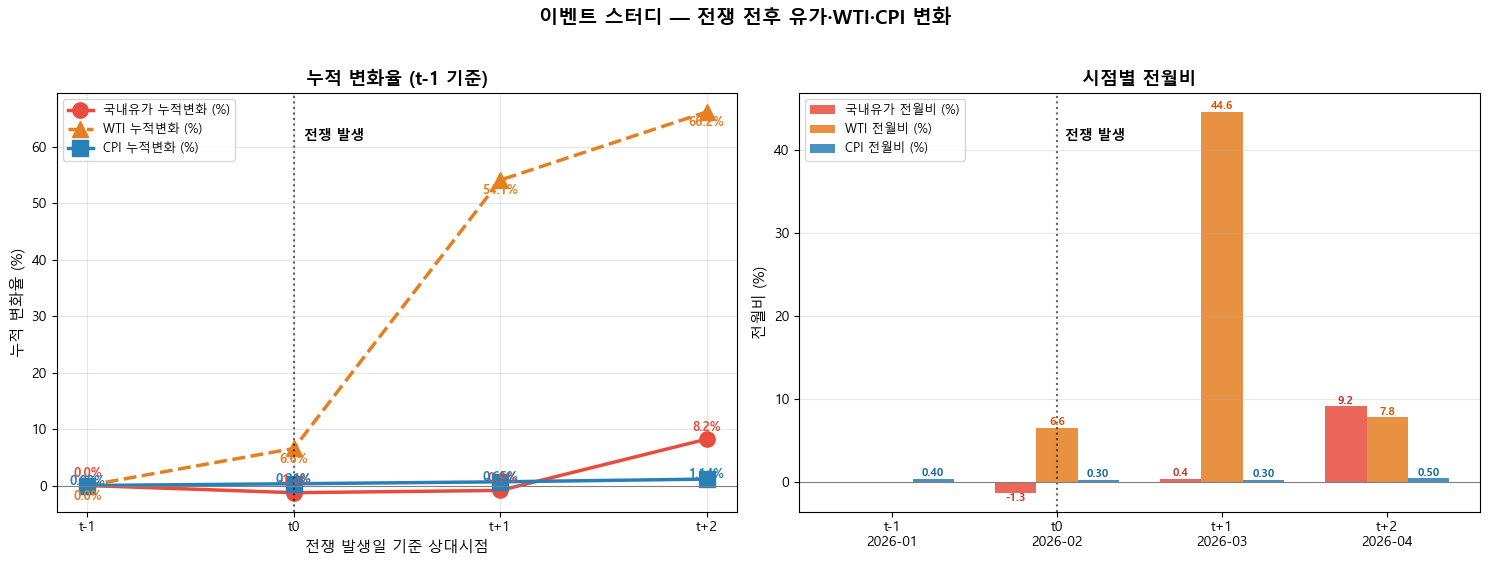

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
t_labels = event['시점'].tolist()

# ── (좌) 누적 변화율 ─────────────────────────────────────────────────────
ax = axes[0]
oil_cum = event['유가_누적변화(%, t-1기준)'].tolist()
wti_cum = ((event['WTI_월평균'] / event['WTI_월평균'].iloc[0]) - 1) * 100
cpi_cum = event['CPI_누적변화(%, t-1기준)'].tolist()

ax.plot(t_labels, oil_cum, marker='o', markersize=11, linewidth=2.5,
        color='#e74c3c', label='국내유가 누적변화 (%)')
ax.plot(t_labels, wti_cum, marker='^', markersize=11, linewidth=2.5,
        color='#e67e22', linestyle='--', label='WTI 누적변화 (%)')
ax.plot(t_labels, cpi_cum, marker='s', markersize=11, linewidth=2.5,
        color='#2980b9', label='CPI 누적변화 (%)')

for i, (o, w, c) in enumerate(zip(oil_cum, wti_cum, cpi_cum)):
    ax.text(i, o + 1.5,  f'{o:.1f}%',  ha='center', color='#e74c3c', fontweight='bold', fontsize=9)
    ax.text(i, w - 2.5,  f'{w:.1f}%',  ha='center', color='#e67e22', fontweight='bold', fontsize=9)
    ax.text(i, c + 0.15, f'{c:.2f}%',  ha='center', color='#2980b9', fontweight='bold', fontsize=9)

ax.axvline(1, color='black', linestyle=':', linewidth=1.5, alpha=0.6)
ax.text(1.05, ax.get_ylim()[1] * 0.88, '전쟁 발생', fontsize=10, color='black', fontweight='bold')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title('누적 변화율 (t-1 기준)', fontsize=13, fontweight='bold')
ax.set_ylabel('누적 변화율 (%)', fontsize=11)
ax.set_xlabel('전쟁 발생일 기준 상대시점', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

# ── (우) 시점별 전월비 ───────────────────────────────────────────────────
ax = axes[1]
oil_mom = event['유가_전월비'].tolist()
wti_mom = event['WTI_전월비'].tolist()
cpi_mom = event['CPI_전월비'].tolist()
x = np.arange(len(t_labels))
w = 0.25

ax.bar(x - w, [v if pd.notna(v) else 0 for v in oil_mom], w,
       label='국내유가 전월비 (%)', color='#e74c3c', alpha=0.85)
ax.bar(x,     [v if pd.notna(v) else 0 for v in wti_mom], w,
       label='WTI 전월비 (%)',     color='#e67e22', alpha=0.85)
ax.bar(x + w, [v if pd.notna(v) else 0 for v in cpi_mom], w,
       label='CPI 전월비 (%)',     color='#2980b9', alpha=0.85)

for i, v in enumerate(oil_mom):
    if pd.notna(v):
        ax.text(i - w, v + 0.3 if v >= 0 else v - 1.0,
                f'{v:.1f}', ha='center', fontsize=8, fontweight='bold', color='#c0392b')
for i, v in enumerate(wti_mom):
    if pd.notna(v):
        ax.text(i, v + 0.3 if v >= 0 else v - 1.0,
                f'{v:.1f}', ha='center', fontsize=8, fontweight='bold', color='#d35400')
for i, v in enumerate(cpi_mom):
    if pd.notna(v):
        ax.text(i + w, v + 0.3 if v >= 0 else v - 1.0,
                f'{v:.2f}', ha='center', fontsize=8, fontweight='bold', color='#1a6695')

ax.set_xticks(x)
ax.set_xticklabels([f'{t}\n{m}' for t, m in zip(t_labels, event['연월'])], fontsize=10)
ax.axvline(1, color='black', linestyle=':', linewidth=1.5, alpha=0.6)
ax.text(1.05, ax.get_ylim()[1] * 0.88, '전쟁 발생', fontsize=10, color='black', fontweight='bold')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title('시점별 전월비', fontsize=13, fontweight='bold')
ax.set_ylabel('전월비 (%)', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('이벤트 스터디 — 전쟁 전후 유가·WTI·CPI 변화', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. 결과 해석 — 전이 시차 도출

### 7-1. 총지수 기준 패턴 (oil_sql 데이터 기반)

| 시점 | 연월 | 국내유가 전월비 | WTI 전월비 | CPI 전월비 | 비고 |
|------|------|:---------:|:---------:|:---------:|------|
| t-1 | 2026-01 | — | — | **+0.4%** | 전쟁 전 안정 구간 |
| t0  | 2026-02 | **-1.3%** | **+6.5%** | **+0.3%** | 전쟁 2/28 발생 — 당월 영향 미반영 |
| t+1 | 2026-03 | **+0.4%** | **+44.6%** | **+0.3%** | WTI 급등, 국내유가·CPI 아직 미반응 |
| t+2 | 2026-04 | **+9.2%** | **+7.8%** | **+0.5%** | 국내유가 본격 반등, CPI 반응 시작 |

> **국내 휘발유가(gasoline)** 는 정부 유류세·정유사 마진 등으로 국제유가보다 수개월 시차 존재
> **WTI** 는 전쟁 직후(3월) 급등, 국내 소비자가는 4월에 반영

### 7-2. 관찰된 전이 시차 요약
- **WTI → CPI**: 약 **2개월** 시차 (3월 급등 → 4월 CPI 반응)
- **국내유가 → CPI**: **동월~1개월** 시차 (4월 유가↑, 4월 CPI↑ 동행)
- ⇒ 가설 2 방향성 지지: 유가 충격이 일정 시차 후 CPI에 전이됨

### 7-3. 해석 ⭐
- 3월의 WTI 쇼크 (+44.6%) — 전쟁 직후 한 달 만에 WTI가 44.6% 급등한 것은 호르무즈 해협 봉쇄 우려 등 공급 충격이 즉각 국제시장에 반영된 결과입니다. 그러나 같은 달 국내유가는 고작 +0.4%, CPI는 +0.30%로 국내에는 거의 전달되지 않았습니다.
- 4월의 연쇄 반응 — WTI 상승세가 +7.8%로 둔화되는 시점에 오히려 국내유가(+9.2%)와 CPI(+0.50%)가 가장 크게 반응합니다. WTI 선행 → 국내유가 후행 → CPI 후후행 의 시차 구조가 수치로 확인됩니다.
- CPI의 절대 변동폭이 매우 작음 — CPI 전월비 최대치가 +0.50%로, 유가 충격 대비 물가 상승은 제한적입니다. 이는 에너지 외 품목들이 안정적으로 유지되었기 때문
- 종합 결론 — 가설 2 검증 ->
"유가 상승이 일정 시차를 두고 국내 CPI에 전이된다"
### 7-4. 분석의 한계
1. **표본 크기**: N=4로 통계적 추론(유의성 검정) 불가 → 정성적 사례연구
2. **단일 사건**: 2026 이란 전쟁이라는 단일 충격 → 일반화 어려움
3. **국내유가 특성**: 정부 유류세 보조금 및 정유사 마진 반영으로 국제유가 대비 완충 효과 존재
4. **혼란요인 미통제**: 환율, 기준금리, 계절성 등 다른 변수 영향 분리 미실시

### 7-5. 후속 연구 제안
- 데이터 기간 확장 후 교차상관함수(CCF) 분석으로 정식 시차 추정
- "WTI → 원/달러 환율 → 국내유가 → CPI" 경로 분해
- 과거 충격(2008, 2014, 2020, 2022) 비교를 통한 일반화 시도